In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.497635,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,-0.747766,0.0,0.600320,0.075008,0.231096
1,-0.473435,0.0,0.0,-1.0,0.0,1.0,-1.0,-1.0,1.0,0.159774,0.0,-0.690705,-0.466877,-0.387041
2,-0.113739,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,1.0,0.610629,1.0,-0.308082,0.641923,0.210342
3,0.826312,0.0,0.0,-1.0,0.0,1.0,-1.0,-1.0,1.0,0.494088,0.0,-0.987020,-0.399206,-0.398539
4,0.596634,0.0,0.0,-1.0,0.0,1.0,-1.0,-1.0,1.0,1.007387,0.0,-0.641777,-0.293211,-0.315926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.747766,0.0,-0.109388,-0.294765,-0.236855
135,0.671213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.747766,1.0,-0.399297,1.027319,0.352293
136,-0.235838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.560275,0.0,0.518153,-0.059989,0.075327
137,0.421516,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.620942,1.0,-0.353490,0.464201,0.118722


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

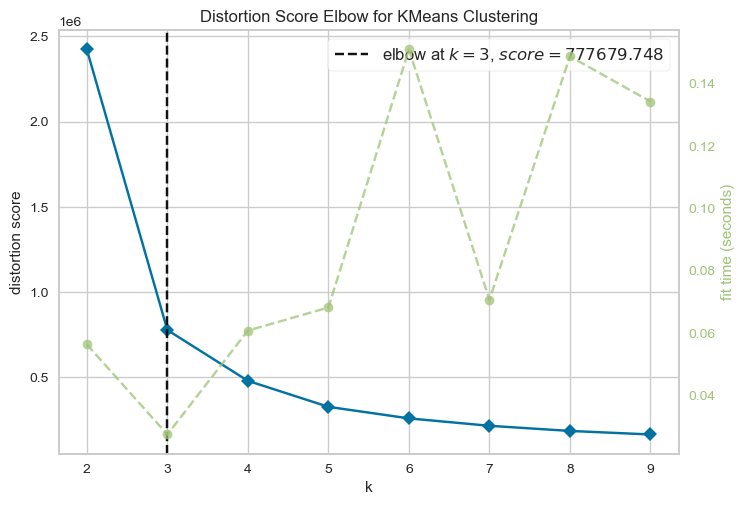

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 3 
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=3)

0
Most correlated column: pack_years
Correlation coefficient: 0.5694924435077031


1
Most correlated column: TLG
Correlation coefficient: 2.3100008968428023


2
Most correlated column: hpv_related
Correlation coefficient: 0.2460640183505367




In [22]:
selected_features

['pack_years', 'TLG', 'hpv_related']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [25]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [26]:
X_new

,pack_years,TLG,hpv_related
0,0.000000,86.228420,0.0
1,27.404795,7.040100,0.0
2,41.019178,83.569669,0.0
3,37.500000,5.567091,0.0
4,53.000000,16.150550,0.0
...,...,...,...
134,0.000000,26.280140,1.0
135,0.000000,101.754834,1.0
136,39.498630,66.273201,1.0
137,71.527397,71.832443,1.0


In [27]:
X_new_std

,pack_years,TLG,hpv_related
0,-0.747766,0.231096,0.0
1,0.159774,-0.387041,0.0
2,0.610629,0.210342,0.0
3,0.494088,-0.398539,0.0
4,1.007387,-0.315926,0.0
...,...,...,...
134,-0.747766,-0.236855,1.0
135,-0.747766,0.352293,1.0
136,0.560275,0.075327,1.0
137,1.620942,0.118722,1.0


In [28]:
MAASTRO_new

,pack_years,TLG,hpv_related
0,0,263.611623,1
1,20,36.980700,0
2,6,74.636342,0
3,45,46.791979,0
4,59,107.637514,1
...,...,...,...
94,55,144.490782,0
95,174,69.214868,0
96,0,102.594274,1
97,0,103.229492,1


In [29]:
MAASTRO_new_std

,pack_years,TLG,hpv_related
0,-0.747766,1.615732,1
1,-0.085444,-0.153327,0
2,-0.549070,0.140609,0
3,0.742458,-0.076742,0
4,1.206084,0.398213,1
...,...,...,...
94,1.073619,0.685886,0
95,5.014436,0.098289,0
96,-0.747766,0.358846,1
97,-0.747766,0.363804,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:40:25,765] A new study created in memory with name: no-name-7594028e-7338-4f77-a87e-f3b345bfa4b3


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8185654008438819


[I 2024-04-13 23:40:26,315] A new study created in memory with name: no-name-67b87a73-90d0-453e-b87b-3d4a5cf0b2d3


Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:40:26,303] Trial 0 finished with value: 0.7379255788686405 and parameters: {}. Best is trial 0 with value: 0.7379255788686405.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7379255788686405], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 25, 848449), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 26, 303227), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7379255788686405


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.18391253727592477
Fold 2 IBS: 0.2352695541158028
Fold 3 IBS: 0.16761118761667607
Fold 4 IBS: 0.1443930694984718
Fold 5 IBS: 0.27253140682392585
[I 2024-04-13 23:40:26,822] Trial 0 finished with value: 0.2007435510661603 and parameters: {}. Best is trial 0 with value: 0.2007435510661603.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2007435510661603], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 26, 353738), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 26, 822588), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2007435510661603


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.738
train_ibs:  0.201


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.578
IBS score: 0.246


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:40:27,076] A new study created in memory with name: no-name-515dbd1d-d27a-4ad6-8398-632bb810937e


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5476190476190477


[I 2024-04-13 23:40:27,395] A new study created in memory with name: no-name-a6798952-3699-4aaa-a258-1d729f3d4236


Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.7426470588235294
Fold 4 C-index: 0.7721518987341772
Fold 5 C-index: 0.568075117370892
[I 2024-04-13 23:40:27,379] Trial 0 finished with value: 0.6564557673666721 and parameters: {}. Best is trial 0 with value: 0.6564557673666721.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6564557673666721], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 27, 112015), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 27, 379186), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6564557673666721


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397652404155967
Fold 2 IBS: 0.22157791236339294
Fold 3 IBS: 0.20453594148299523
Fold 4 IBS: 0.224738034839535
Fold 5 IBS: 0.218124314720505
[I 2024-04-13 23:40:27,789] Trial 0 finished with value: 0.2165905454895976 and parameters: {}. Best is trial 0 with value: 0.2165905454895976.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905454895976], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 27, 425403), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 27, 789254), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905454895976


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.656
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.512


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:40:28,120] A new study created in memory with name: no-name-de30c1fd-fc81-4177-9187-b9cc56fd0e26


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647


[I 2024-04-13 23:40:28,758] A new study created in memory with name: no-name-d5039bd6-4dc5-4712-a16a-c6a09b97360b


Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:40:28,739] Trial 0 finished with value: 0.7370816970121004 and parameters: {}. Best is trial 0 with value: 0.7370816970121004.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7370816970121004], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 28, 179491), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 28, 739313), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7370816970121004


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1845490294048349
Fold 2 IBS: 0.23355260324041244
Fold 3 IBS: 0.16762367356386917
Fold 4 IBS: 0.14580355369437026
Fold 5 IBS: 0.27031947503246934
[I 2024-04-13 23:40:29,465] Trial 0 finished with value: 0.20036966698719122 and parameters: {}. Best is trial 0 with value: 0.20036966698719122.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20036966698719122], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 28, 797229), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 29, 465502), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20036966698719122


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.737
train_ibs:  0.2


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.577


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.245


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:40:29,905] A new study created in memory with name: no-name-340a95f0-6a1b-4bb8-97ba-abf94168114f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:40:30,487] Trial 0 finished with value: 0.7361427298759502 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7361427298759502.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:40:31,185] Trial 1 finished with value: 0.7361427298759502 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7361427298759502.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:40:31,893] Trial 2 finished with value: 0.7361427298759502 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:40:46,250] Trial 24 finished with value: 0.7361427298759502 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.7370816970121004.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:40:46,926] Trial 25 finished with value: 0.7370816970121004 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.7370816970121004.
Fold 1 C-index: 0.5584415584415584
Fold 2 C-index: 0.6383928571428571
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.7848101265822784
Fold 5 C-index: 0.5821596244131455
[I 2024-04-13 23:40:47,214] Trial 26 finished with value: 0.6608000490022424 and parameters: {'l1_ratio': 0.01542375755129554

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:41:01,505] Trial 48 finished with value: 0.7370816970121004 and parameters: {'l1_ratio': 0.8619031648167028}. Best is trial 6 with value: 0.7370816970121004.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:41:02,422] Trial 49 finished with value: 0.7370816970121004 and parameters: {'l1_ratio': 0.920787420171088}. Best is trial 6 with value: 0.7370816970121004.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.7098214285714286
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6291079812206573
[I 2024-04-13 23:41:03,199] Trial 50 finished with value: 0.7361427298759502 and parameters: {'l1_ratio': 0.8176586649944165}.

...

Fold 1 IBS: 0.1845982613548652
Fold 2 IBS: 0.23319265710322562
Fold 3 IBS: 0.16745941407457
Fold 4 IBS: 0.14585505802309975
Fold 5 IBS: 0.27005942894034995
[I 2024-04-13 23:41:34,202] Trial 0 finished with value: 0.2002329638992221 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.2002329638992221.
Fold 1 IBS: 0.18478985544145668
Fold 2 IBS: 0.2330488310038529
Fold 3 IBS: 0.16725943918592454
Fold 4 IBS: 0.14582946451032705
Fold 5 IBS: 0.2700388151629343
[I 2024-04-13 23:41:34,985] Trial 1 finished with value: 0.20019328106089912 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.20019328106089912.
Fold 1 IBS: 0.18476111100819245
Fold 2 IBS: 0.23307133173166006
Fold 3 IBS: 0.16721511375786455
Fold 4 IBS: 0.1457501189966167
Fold 5 IBS: 0.2701048783260502
[I 2024-04-13 23:41:35,823] Trial 2 finished with value: 0.20018051076407678 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.20018051076407678.


Fold 1 IBS: 0.18479553293982284
Fold 2 IBS: 0.23289783876970802
Fold 3 IBS: 0.16718911800038733
Fold 4 IBS: 0.14574450633103425
Fold 5 IBS: 0.2699865289044103
[I 2024-04-13 23:41:57,192] Trial 25 finished with value: 0.20012270498907253 and parameters: {'l1_ratio': 0.11645578179592492}. Best is trial 25 with value: 0.20012270498907253.
Fold 1 IBS: 0.18479055091149268
Fold 2 IBS: 0.2329632293690391
Fold 3 IBS: 0.16721744420151696
Fold 4 IBS: 0.1457731986463691
Fold 5 IBS: 0.2700142894537086
[I 2024-04-13 23:41:58,202] Trial 26 finished with value: 0.20015174251642529 and parameters: {'l1_ratio': 0.1837586030278669}. Best is trial 25 with value: 0.20012270498907253.
Fold 1 IBS: 0.18475232958150128
Fold 2 IBS: 0.2330039286635181
Fold 3 IBS: 0.16727462869507845
Fold 4 IBS: 0.14580657382639203
Fold 5 IBS: 0.27015705237463594
[I 2024-04-13 23:41:58,994] Trial 27 finished with value: 0.2001989026282252 and parameters: {'l1_ratio': 0.3546605785429995}. Best is trial 25 with value: 0.2001227049

Fold 5 IBS: 0.2699685415068077
[I 2024-04-13 23:42:18,824] Trial 49 finished with value: 0.20014608109467713 and parameters: {'l1_ratio': 0.1970767181459351}. Best is trial 25 with value: 0.20012270498907253.
Fold 1 IBS: 0.18483220535323455
Fold 2 IBS: 0.2330149106368988
Fold 3 IBS: 0.16717589732450053
Fold 4 IBS: 0.14580409805373723
Fold 5 IBS: 0.2701089495344492
[I 2024-04-13 23:42:20,538] Trial 50 finished with value: 0.20018721218056407 and parameters: {'l1_ratio': 0.12243801272317634}. Best is trial 25 with value: 0.20012270498907253.
Fold 1 IBS: 0.18483010562206
Fold 2 IBS: 0.23299849397519715
Fold 3 IBS: 0.16716524902916907
Fold 4 IBS: 0.14578485646737604
Fold 5 IBS: 0.27010846239919223
[I 2024-04-13 23:42:22,000] Trial 51 finished with value: 0.2001774334985989 and parameters: {'l1_ratio': 0.09341981770248678}. Best is trial 25 with value: 0.20012270498907253.
Fold 1 IBS: 0.21501968868426152
Fold 2 IBS: 0.23283550818170246
Fold 3 IBS: 0.16715836277688412
Fold 4 IBS: 0.222535199

Fold 2 IBS: 0.2330415250860509
Fold 3 IBS: 0.16719492308550238
Fold 4 IBS: 0.1457155306657586
Fold 5 IBS: 0.2701058439327659
[I 2024-04-13 23:42:48,129] Trial 74 finished with value: 0.2001791078925433 and parameters: {'l1_ratio': 0.17457408065542734}. Best is trial 73 with value: 0.20011951631388084.
Fold 1 IBS: 0.1848621229120546
Fold 2 IBS: 0.23294097741763073
Fold 3 IBS: 0.1671967748172558
Fold 4 IBS: 0.14572112480703278
Fold 5 IBS: 0.2700316430724001
[I 2024-04-13 23:42:49,098] Trial 75 finished with value: 0.2001505286052748 and parameters: {'l1_ratio': 0.11859491495761101}. Best is trial 73 with value: 0.20011951631388084.
Fold 1 IBS: 0.18486699793044467
Fold 2 IBS: 0.2328864652777125
Fold 3 IBS: 0.16717363672281052
Fold 4 IBS: 0.221013795711409
Fold 5 IBS: 0.2700073605610202
[I 2024-04-13 23:42:49,925] Trial 76 finished with value: 0.21518965124067937 and parameters: {'l1_ratio': 0.06225318626097946}. Best is trial 73 with value: 0.20011951631388084.
Fold 1 IBS: 0.1848218018408

Fold 1 IBS: 0.1848063392809066
Fold 2 IBS: 0.23290827326244323
Fold 3 IBS: 0.1672036821890915
Fold 4 IBS: 0.14578763694094266
Fold 5 IBS: 0.2699665448764669
[I 2024-04-13 23:43:11,862] Trial 99 finished with value: 0.20013449530997018 and parameters: {'l1_ratio': 0.16510445889904285}. Best is trial 83 with value: 0.20011775903517645.


* Best trial for IBS: 
 FrozenTrial(number=83, state=TrialState.COMPLETE, values=[0.20011775903517645], datetime_start=datetime.datetime(2024, 4, 13, 23, 42, 54, 811469), datetime_complete=datetime.datetime(2024, 4, 13, 23, 42, 56, 343622), params={'l1_ratio': 0.06698006422194244}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=83, value=None)


* Best Score for IBS: 
 0.20011775903517645


In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.737
train_ibs:  0.2


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.577


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.06698006422194244)

test_ibs:  0.246


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:43:12,554] A new study created in memory with name: no-name-d75ddbe4-4f82-4814-92fd-dee143406543


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7359307359307359
Fold 2 C-index: 0.6584821428571429
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.6150234741784038
[I 2024-04-13 23:43:21,377] Trial 0 finished with value: 0.72738987669899 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.72738987669899.
Fold 1 C-index: 0.7251082251082251
Fold 2 C-index: 0.6941964285714286
Fold 3 C-index: 0.875
Fold 4 C-index: 0.8734177215189873
Fold 5 C-index: 0.596244131455399
[I 2024-04-13 23:43:28,621] Trial 1 finished with value: 0.7527933013308081 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_features': 's

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.7321428571428571
Fold 3 C-index: 0.7965686274509803
Fold 4 C-index: 0.820675105485232
Fold 5 C-index: 0.6619718309859155
[I 2024-04-13 23:45:09,593] Trial 16 finished with value: 0.7485920305333433 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 7, 'n_estimators': 62, 'oob_score': True, 'max_samples': 0.8669301717284132, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.37909912926450273, 'warm_start': True}. Best is trial 15 with value: 0.7762052465802282.
Fold 1 C-index: 0.7445887445887446
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.8382352941176471
Fold 4 C-index: 0.8628691983122363
Fold 5 C-index: 0.6643192488262911
[I 2024-04-13 23:45:11,587] Trial 17 finished with value: 0.7737882114546981 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 15, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.9849962225668187

Fold 1 C-index: 0.6991341991341992
Fold 2 C-index: 0.8147321428571429
Fold 3 C-index: 0.821078431372549
Fold 4 C-index: 0.8734177215189873
Fold 5 C-index: 0.7699530516431925
[I 2024-04-13 23:45:51,117] Trial 31 finished with value: 0.7956631093052142 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 13, 'min_samples_leaf': 7, 'max_depth': 5, 'n_estimators': 238, 'oob_score': True, 'max_samples': 0.8014072764177669, 'max_features': None, 'min_weight_fraction_leaf': 0.02229469155676539, 'warm_start': True}. Best is trial 31 with value: 0.7956631093052142.
Fold 1 C-index: 0.6948051948051948
Fold 2 C-index: 0.8236607142857143
Fold 3 C-index: 0.8308823529411765
Fold 4 C-index: 0.869198312236287
Fold 5 C-index: 0.7746478873239436
[I 2024-04-13 23:45:53,747] Trial 32 finished with value: 0.7986388923184633 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 8, 'min_samples_leaf': 7, 'max_depth': 5, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.7710633822842887, 'max

...

Fold 5 IBS: 0.23519914561526403
[I 2024-04-14 00:03:59,914] Trial 31 finished with value: 0.19126075351403066 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 14, 'min_samples_leaf': 5, 'max_depth': 16, 'n_estimators': 248, 'oob_score': True, 'max_samples': 0.29146649016221915, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.04947531763691557}. Best is trial 14 with value: 0.18724409851178564.
Fold 1 IBS: 0.1829374937829002
Fold 2 IBS: 0.20728582622665243
Fold 3 IBS: 0.17474093984667047
Fold 4 IBS: 0.17567320312846593
Fold 5 IBS: 0.22503122155735408
[I 2024-04-14 00:04:15,550] Trial 32 finished with value: 0.19313373690840863 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 17, 'n_estimators': 310, 'oob_score': True, 'max_samples': 0.11948341591639726, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.028956113086755074}. Best is trial 14 with value: 0.18724409851178564.
Fold 1 IBS: 0.1625692333783063
Fold 2 IBS: 0.2

Fold 1 IBS: 0.178716469174805
Fold 2 IBS: 0.21247566834937667
Fold 3 IBS: 0.1674784180672118
Fold 4 IBS: 0.16837787537325127
Fold 5 IBS: 0.23301012323988993
[I 2024-04-14 00:07:08,222] Trial 47 finished with value: 0.19201171084090693 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 13, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 139, 'oob_score': False, 'max_samples': 0.3816699163113005, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.08294241850665368}. Best is trial 14 with value: 0.18724409851178564.
Fold 1 IBS: 0.1813071899205523
Fold 2 IBS: 0.21448399943170113
Fold 3 IBS: 0.1675723860177231
Fold 4 IBS: 0.1690153702303558
Fold 5 IBS: 0.23826179945505152
[I 2024-04-14 00:07:19,171] Trial 48 finished with value: 0.19412814901107675 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 15, 'min_samples_leaf': 14, 'max_depth': 8, 'n_estimators': 199, 'oob_score': True, 'max_samples': 0.7846145083122456, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22648524955318788
[I 2024-04-14 00:09:41,843] Trial 62 finished with value: 0.1901848987759851 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 165, 'oob_score': True, 'max_samples': 0.1030220442627847, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.0016896264717097755}. Best is trial 14 with value: 0.18724409851178564.
Fold 1 IBS: 0.18170080475027373
Fold 2 IBS: 0.20581220990604657
Fold 3 IBS: 0.17561624758019473
Fold 4 IBS: 0.17204144853310174
Fold 5 IBS: 0.22389610173719332
[I 2024-04-14 00:09:51,432] Trial 63 finished with value: 0.191813362501362 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 192, 'oob_score': True, 'max_samples': 0.14216657532349047, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.02043985854341805}. Best is trial 14 with value: 0.18724409851178564.
Fold 1 IBS: 0.178057471914892
Fold 2 IBS: 0.2080

Fold 1 IBS: 0.17723136261831895
Fold 2 IBS: 0.21712687340835382
Fold 3 IBS: 0.16350648913840493
Fold 4 IBS: 0.16296715338430082
Fold 5 IBS: 0.23982245701864038
[I 2024-04-14 00:31:35,951] Trial 78 finished with value: 0.19213086711360378 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 189, 'oob_score': True, 'max_samples': 0.465343661986069, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.0722106485501219}. Best is trial 14 with value: 0.18724409851178564.
Fold 1 IBS: 0.17727108937989902
Fold 2 IBS: 0.22584219835733638
Fold 3 IBS: 0.1668036314828863
Fold 4 IBS: 0.1544756920951059
Fold 5 IBS: 0.26012339269821716
[I 2024-04-14 00:31:47,577] Trial 79 finished with value: 0.19690320080268894 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 13, 'min_samples_leaf': 6, 'max_depth': 17, 'n_estimators': 109, 'oob_score': True, 'max_samples': 0.3972943685715824, 'max_features': None, 'min_weight_fraction_leaf'

Fold 5 IBS: 0.23589426034467184
[I 2024-04-14 00:34:55,821] Trial 93 finished with value: 0.18854792223127526 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 11, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 248, 'oob_score': True, 'max_samples': 0.19218917014289924, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.025845913819460588}. Best is trial 84 with value: 0.18717616615669047.
Fold 1 IBS: 0.21394127885820519
Fold 2 IBS: 0.22042019099063978
Fold 3 IBS: 0.2051471604115031
Fold 4 IBS: 0.22505903464644447
Fold 5 IBS: 0.21704154839685838
[I 2024-04-14 00:35:10,071] Trial 94 finished with value: 0.2163218426607302 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 15, 'n_estimators': 306, 'oob_score': True, 'max_samples': 0.1262673154900722, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19325758482297192}. Best is trial 84 with value: 0.18717616615669047.
Fold 1 IBS: 0.18066936586068758
Fold 2 IBS: 0.20

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.837
train_ibs:  0.187


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=7, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.9270218595511445, min_samples_leaf=5,
                     min_samples_split=12,
                     min_weight_fraction_leaf=0.04731727049932451,
                     n_estimators=500, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.656


RandomSurvivalForest(max_depth=13, max_features='log2', max_leaf_nodes=11,
                     max_samples=0.14535567347576336, min_samples_leaf=2,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.001882343976116397,
                     n_estimators=254, oob_score=True, random_state=123)

test_ibs:  0.206


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:36:37,441] A new study created in memory with name: no-name-64657b95-08ac-4a8c-ae98-82e9b65fc0dd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7532467532467533
Fold 2 C-index: 0.7433035714285714
Fold 3 C-index: 0.8357843137254902
Fold 4 C-index: 0.869198312236287
Fold 5 C-index: 0.6572769953051644
[I 2024-04-14 00:36:40,670] Trial 0 finished with value: 0.7717619891884533 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7717619891884533.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:36:49,233] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 1 C-index: 0.7597402597402597
Fold 2 C-index: 0.7142857142857143
Fold 3 C-index: 0.7867647058823529
Fold 4 C-index: 0.8354430379746836
Fold 5 C-index: 0.6408450704225352
[I 2024-04-14 00:38:37,439] Trial 16 finished with value: 0.7474157576611091 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.7796024701311504.
Fold 1 C-index: 0.7597402597402597
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7671568627450981
Fold 4 C-index: 0.8502109704641351
Fold 5 C-index: 0.5845070422535211
[I 2024-04-14 00:38:42,568] Trial 17 finished with value: 0.731608741326317 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featur

Fold 1 C-index: 0.7748917748917749
Fold 2 C-index: 0.734375
Fold 3 C-index: 0.8382352941176471
Fold 4 C-index: 0.8734177215189873
Fold 5 C-index: 0.6901408450704225
[I 2024-04-14 00:39:39,978] Trial 31 finished with value: 0.7822121271197664 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 337, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9359036874686182, 'min_weight_fraction_leaf': 0.043457520259011145}. Best is trial 31 with value: 0.7822121271197664.
Fold 1 C-index: 0.7575757575757576
Fold 2 C-index: 0.7299107142857143
Fold 3 C-index: 0.8382352941176471
Fold 4 C-index: 0.8649789029535865
Fold 5 C-index: 0.6901408450704225
[I 2024-04-14 00:39:43,204] Trial 32 finished with value: 0.7761683028006255 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 6, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 282, 'oob_score': False, 'warm_start': True, 'max_features': 'log

...

Fold 1 IBS: 0.18361198008764518
Fold 2 IBS: 0.21754069340601034
Fold 3 IBS: 0.187975346711006
Fold 4 IBS: 0.1886586641031656
Fold 5 IBS: 0.2264251441740241
[I 2024-04-14 00:49:13,231] Trial 30 finished with value: 0.2008423656963702 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 71, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8258632202024414, 'min_weight_fraction_leaf': 0.20241101766143602}. Best is trial 7 with value: 0.19459849550301783.
Fold 1 IBS: 0.178345062403997
Fold 2 IBS: 0.21524954811609537
Fold 3 IBS: 0.18188938216390743
Fold 4 IBS: 0.18215088785880523
Fold 5 IBS: 0.2273125667046601
[I 2024-04-14 00:49:17,940] Trial 31 finished with value: 0.19698948944949302 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 16, 'n_estimators': 133, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.60

Fold 1 IBS: 0.16958233237410647
Fold 2 IBS: 0.2215908866125608
Fold 3 IBS: 0.17705590914034003
Fold 4 IBS: 0.1720069218082126
Fold 5 IBS: 0.22721694983642465
[I 2024-04-14 00:50:46,121] Trial 45 finished with value: 0.1934905999543289 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 89, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9986783002201525, 'min_weight_fraction_leaf': 0.004760507523990938}. Best is trial 45 with value: 0.1934905999543289.
Fold 1 IBS: 0.16389096110915455
Fold 2 IBS: 0.22205966739948704
Fold 3 IBS: 0.1741978290581002
Fold 4 IBS: 0.16719137298661685
Fold 5 IBS: 0.22680292201048466
[I 2024-04-14 00:50:49,038] Trial 46 finished with value: 0.19082855051276867 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 19, 'n_estimators': 83, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0

Fold 1 IBS: 0.1703381237370587
Fold 2 IBS: 0.22100158376005705
Fold 3 IBS: 0.1784413972321202
Fold 4 IBS: 0.17622860086228082
Fold 5 IBS: 0.22702592557138845
[I 2024-04-14 00:51:19,975] Trial 60 finished with value: 0.19460712623258108 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 4, 'n_estimators': 74, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9689251665182579, 'min_weight_fraction_leaf': 0.06591548164196206}. Best is trial 55 with value: 0.1899060815123468.
Fold 1 IBS: 0.17038567549718298
Fold 2 IBS: 0.2321609016179255
Fold 3 IBS: 0.17411273969946048
Fold 4 IBS: 0.16228095528132103
Fold 5 IBS: 0.23975530978769943
[I 2024-04-14 00:51:21,691] Trial 61 finished with value: 0.19573911637671787 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 6, 'n_estimators': 30, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9

Fold 1 IBS: 0.15054614288142887
Fold 2 IBS: 0.24816442598674104
Fold 3 IBS: 0.17470276649808908
Fold 4 IBS: 0.14663651708690612
Fold 5 IBS: 0.271576430515875
[I 2024-04-14 00:51:54,257] Trial 75 finished with value: 0.198325256593808 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 18, 'min_samples_leaf': 1, 'max_depth': 4, 'n_estimators': 45, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.8788627102948032, 'min_weight_fraction_leaf': 0.06066317729090221}. Best is trial 55 with value: 0.1899060815123468.
Fold 1 IBS: 0.17962107634169855
Fold 2 IBS: 0.22577003637096738
Fold 3 IBS: 0.18207094683856
Fold 4 IBS: 0.17450993708332338
Fold 5 IBS: 0.23143770016136098
[I 2024-04-14 00:51:56,235] Trial 76 finished with value: 0.19868193935918205 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 8, 'n_estimators': 28, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.845741846

Fold 1 IBS: 0.182811010282934
Fold 2 IBS: 0.21494421419671486
Fold 3 IBS: 0.1853462228985213
Fold 4 IBS: 0.18750176692587953
Fold 5 IBS: 0.22329847765259575
[I 2024-04-14 00:53:01,459] Trial 90 finished with value: 0.19878033839132908 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 1, 'n_estimators': 236, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.8994662862060075, 'min_weight_fraction_leaf': 0.04844299979506143}. Best is trial 83 with value: 0.18851683632135258.
Fold 1 IBS: 0.15857702333519402
Fold 2 IBS: 0.22215965499313986
Fold 3 IBS: 0.1731447115712273
Fold 4 IBS: 0.16175574672123869
Fold 5 IBS: 0.229442496188105
[I 2024-04-14 00:53:07,346] Trial 91 finished with value: 0.18901592656178096 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 152, 'oob_score': False, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.93780495

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.783
train_ibs:  0.188


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=13, max_features='log2', max_leaf_nodes=8,
                   max_samples=0.9227991076405792, min_samples_leaf=9,
                   min_samples_split=19,
                   min_weight_fraction_leaf=0.03377901344710234,
                   n_estimators=352, random_state=123, warm_start=True)

C-index score: 0.657


ExtraSurvivalTrees(max_depth=4, max_features=0.1, max_leaf_nodes=17,
                   max_samples=0.8364715654681891, min_samples_leaf=2,
                   min_samples_split=3,
                   min_weight_fraction_leaf=0.02158492350856952,
                   n_estimators=153, random_state=123)

IBS: 0.203


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:53:55,652] A new study created in memory with name: no-name-7f55ad42-8dd6-49a8-8839-cdbcd10cb4e1


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:54:53,170] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:55:23,759] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:11:07,071] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7190333030811962.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:12:58,812] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:31:35,646] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7190333030811962.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5868544600938967
[I 2024-04-14 01:33:44,533] Trial 26 finished with value: 0.5374601777330652 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'fried

...

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 04:32:21,858] Trial 55 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8826224600403735, 'learning_rate': 0.007074424640763303, 'dropout_rate': 0.13451729459411277, 'n_estimators': 150, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.2467647950019329, 'max_features': None, 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8026232644824398, 'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 16}. Best is trial 32 with value: 0.21575709156118203.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 04:32:34,848] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.28235337567058344, 'learning_rate': 0.09850922090204048, 'dropout_rate': 0.24047

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 04:47:47,637] Trial 66 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9994775442301681, 'learning_rate': 0.01676432497697686, 'dropout_rate': 0.2942603509282204, 'n_estimators': 8, 'criterion': 'squared_error', 'ccp_alpha': 1.301982997504856, 'min_weight_fraction_leaf': 0.2840514882476357, 'max_features': 'auto', 'min_impurity_decrease': 5.794511488038249e-07, 'validation_fraction': 0.7847157067637343, 'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 19, 'max_depth': 14}. Best is trial 32 with value: 0.21575709156118203.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 04:50:16,920] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7752653699906195, 'learning_rate': 0.013816164977086237, 'dropout_rate': 0.34236599

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 05:11:48,449] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7520083638891345, 'learning_rate': 0.01943171263548099, 'dropout_rate': 0.28850742377580646, 'n_estimators': 491, 'criterion': 'squared_error', 'ccp_alpha': 8.542743935607671, 'min_weight_fraction_leaf': 0.2227746203792833, 'max_features': 1, 'min_impurity_decrease': 1.032492277646189e-05, 'validation_fraction': 0.22171804936592387, 'min_samples_split': 18, 'max_leaf_nodes': 14, 'min_samples_leaf': 12, 'max_depth': 2}. Best is trial 32 with value: 0.21575709156118203.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:15:12,168] Trial 78 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.831497036955375, 'learning_rate': 0.04198098533513253, 'dropout_rate': 0.11973039797

Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:39:00,758] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.87891572853063, 'learning_rate': 0.0036268920527572322, 'dropout_rate': 0.3196243460718578, 'n_estimators': 305, 'criterion': 'squared_error', 'ccp_alpha': 1.5411758839701921, 'min_weight_fraction_leaf': 0.17695684552791566, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0011701047770450368, 'validation_fraction': 0.9308193903518946, 'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 13, 'max_depth': 6}. Best is trial 32 with value: 0.21575709156118203.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560958
[I 2024-04-14 05:41:58,690] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8229491833701941, 'learning_rate': 0.007486747435102087, 'dropout_rate': 0.2503

Fold 4 IBS: 0.21784061671025243
Fold 5 IBS: 0.21900943283472063
[I 2024-04-14 06:05:50,624] Trial 99 finished with value: 0.2133412019681244 and parameters: {'subsample': 0.4750010457704055, 'learning_rate': 0.020609369694162872, 'dropout_rate': 0.10216550214025771, 'n_estimators': 479, 'criterion': 'squared_error', 'ccp_alpha': 0.004453709757441967, 'min_weight_fraction_leaf': 0.16428178441104374, 'max_features': 'auto', 'min_impurity_decrease': 1.5199520188031224e-06, 'validation_fraction': 0.6892196857351478, 'min_samples_split': 13, 'max_leaf_nodes': 19, 'min_samples_leaf': 13, 'max_depth': 17}. Best is trial 99 with value: 0.2133412019681244.


* Best trial for IBS: 
 FrozenTrial(number=99, state=TrialState.COMPLETE, values=[0.2133412019681244], datetime_start=datetime.datetime(2024, 4, 14, 6, 2, 27, 902845), datetime_complete=datetime.datetime(2024, 4, 14, 6, 5, 50, 622883), params={'subsample': 0.4750010457704055, 'learning_rate': 0.020609369694162872, 'dropout_rate': 0.10216550

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.746
train_ibs:  0.213


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.0027453012957063296,
                                 criterion='squared_error',
                                 dropout_rate=0.16863518547083306,
                                 learning_rate=0.031006024334774583,
                                 max_depth=2, max_features=0.1,
                                 max_leaf_nodes=17,
                                 min_impurity_decrease=5.058285588980602e-07,
                                 min_samples_leaf=12,
                                 min_weight_fraction_leaf=0.191361328588429,
                                 n_estimators=216, random_state=123,
                                 subsample=0.9311291803826592,
                                 validation_fraction=0.7930049821598664)

C-index score: 0.62


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004453709757441967,
                                 criterion='squared_error',
                                 dropout_rate=0.10216550214025771,
                                 learning_rate=0.020609369694162872,
                                 max_depth=17, max_features='auto',
                                 max_leaf_nodes=19,
                                 min_impurity_decrease=1.5199520188031224e-06,
                                 min_samples_leaf=13, min_samples_split=13,
                                 min_weight_fraction_leaf=0.16428178441104374,
                                 n_estimators=479, random_state=123,
                                 subsample=0.4750010457704055,
                                 validation_fraction=0.6892196857351478)

IBS: 0.217


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:06:40,255] A new study created in memory with name: no-name-23925624-5ce0-4e86-9224-bf2b580f3b2a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7230392156862745
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.5774647887323944
[I 2024-04-14 06:06:42,493] Trial 0 finished with value: 0.6652476582457811 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6652476582457811.
Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.625
Fold 3 C-index: 0.7205882352941176
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.5774647887323944
[I 2024-04-14 06:07:03,363] Trial 1 finished with value: 0.6647574621673498 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6652476582457811.
Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7205882352941176
Fold 4 C-index: 0.7383966244725

Fold 1 C-index: 0.683982683982684
Fold 2 C-index: 0.6428571428571429
Fold 3 C-index: 0.7549019607843137
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.5774647887323944
[I 2024-04-14 06:09:39,655] Trial 19 finished with value: 0.6879594587312227 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 12 with value: 0.6997926498838243.
Fold 1 C-index: 0.658008658008658
Fold 2 C-index: 0.6428571428571429
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.5774647887323944
[I 2024-04-14 06:09:58,435] Trial 20 finished with value: 0.6746236756262661 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 12 with value: 0.6997926498838243.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.6428571428571429
Fold 3 C-index: 0.7549019607843137
Fo

Fold 1 C-index: 0.6926406926406926
Fold 2 C-index: 0.6339285714285714
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.7383966244725738
Fold 5 C-index: 0.5727699530516432
[I 2024-04-14 06:13:20,258] Trial 38 finished with value: 0.674605991848108 and parameters: {'subsample': 0.3297325755614151, 'dropout_rate': 0.8867789132968811, 'n_estimators': 392, 'learning_rate': 0.08480908032505553}. Best is trial 12 with value: 0.6997926498838243.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.6428571428571429
Fold 3 C-index: 0.7401960784313726
Fold 4 C-index: 0.7763713080168776
Fold 5 C-index: 0.5774647887323944
[I 2024-04-14 06:13:23,282] Trial 39 finished with value: 0.6807111969408908 and parameters: {'subsample': 0.1910828860959901, 'dropout_rate': 0.29848665859072016, 'n_estimators': 145, 'learning_rate': 0.06892741183938003}. Best is trial 12 with value: 0.6997926498838243.
Fold 1 C-index: 0.6666666666666666
Fold 2 C-index: 0.6294642857142857
Fold 3 C-index: 0.7205882352941176
F

...

Fold 3 IBS: 0.1790326284912367
Fold 4 IBS: 0.19516773352117672
Fold 5 IBS: 0.22774051892299596
[I 2024-04-14 06:26:10,533] Trial 19 finished with value: 0.20121278478868826 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.20121278478868826.
Fold 1 IBS: 0.19942749363819642
Fold 2 IBS: 0.20624766757305643
Fold 3 IBS: 0.18189962957561362
Fold 4 IBS: 0.19674777432773993
Fold 5 IBS: 0.22541092607512286
[I 2024-04-14 06:26:11,507] Trial 20 finished with value: 0.20194669823794587 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 19 with value: 0.20121278478868826.
Fold 1 IBS: 0.2004780750166556
Fold 2 IBS: 0.20874280137507
Fold 3 IBS: 0.18553717407508358
Fold 4 IBS: 0.20290168255368587
Fold 5 IBS: 0.22255184936527464
[I 2024-04-14 06:26:12,337] Trial 21 finis

Fold 3 IBS: 0.24188861693326721
Fold 4 IBS: 0.2738536181039761
Fold 5 IBS: 0.32794896935613344
[I 2024-04-14 06:26:59,024] Trial 38 finished with value: 0.2917459750961882 and parameters: {'subsample': 0.7777253891180733, 'dropout_rate': 0.7436024871733287, 'n_estimators': 201, 'learning_rate': 0.06653277770487352}. Best is trial 19 with value: 0.20121278478868826.
Fold 1 IBS: 0.20462941139036664
Fold 2 IBS: 0.2672343854825097
Fold 3 IBS: 0.19993366339131333
Fold 4 IBS: 0.190595194516702
Fold 5 IBS: 0.28349564616746864
[I 2024-04-14 06:27:02,500] Trial 39 finished with value: 0.2291776601896721 and parameters: {'subsample': 0.4520157276673429, 'dropout_rate': 0.6691369306138193, 'n_estimators': 165, 'learning_rate': 0.0349266652565066}. Best is trial 19 with value: 0.20121278478868826.
Fold 1 IBS: 0.2004521688282545
Fold 2 IBS: 0.20535567522400597
Fold 3 IBS: 0.1821777440159023
Fold 4 IBS: 0.20329384884547202
Fold 5 IBS: 0.2222343791988311
[I 2024-04-14 06:27:03,382] Trial 40 finished 

Fold 3 IBS: 0.17674628188741012
Fold 4 IBS: 0.18567383243856134
Fold 5 IBS: 0.23250286117260469
[I 2024-04-14 06:27:30,114] Trial 57 finished with value: 0.19957036787844645 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.5117214056495786, 'n_estimators': 50, 'learning_rate': 0.049700147062680104}. Best is trial 57 with value: 0.19957036787844645.
Fold 1 IBS: 0.18996541474175058
Fold 2 IBS: 0.25555336459670613
Fold 3 IBS: 0.17720354776709973
Fold 4 IBS: 0.16927579303238854
Fold 5 IBS: 0.2830517086778781
[I 2024-04-14 06:27:33,017] Trial 58 finished with value: 0.2150099657631646 and parameters: {'subsample': 0.12356640965441083, 'dropout_rate': 0.36573681723837637, 'n_estimators': 132, 'learning_rate': 0.04968093439861571}. Best is trial 57 with value: 0.19957036787844645.
Fold 1 IBS: 0.25065654071175697
Fold 2 IBS: 0.31655271656530787
Fold 3 IBS: 0.22819155506469121
Fold 4 IBS: 0.2334228525385604
Fold 5 IBS: 0.3260214324794355
[I 2024-04-14 06:27:45,526] Trial 59 

Fold 3 IBS: 0.18048050637647564
Fold 4 IBS: 0.17879418448735113
Fold 5 IBS: 0.26825515980601145
[I 2024-04-14 06:28:16,924] Trial 76 finished with value: 0.21259372367095045 and parameters: {'subsample': 0.22167168741279358, 'dropout_rate': 0.5932469232662346, 'n_estimators': 166, 'learning_rate': 0.03010030603380331}. Best is trial 68 with value: 0.19938774785598415.
Fold 1 IBS: 0.21464934201770386
Fold 2 IBS: 0.2805395419073807
Fold 3 IBS: 0.20567185801574384
Fold 4 IBS: 0.19371837182037552
Fold 5 IBS: 0.2986930713153806
[I 2024-04-14 06:28:22,668] Trial 77 finished with value: 0.2386544370153169 and parameters: {'subsample': 0.26032391203378896, 'dropout_rate': 0.6398491060713013, 'n_estimators': 227, 'learning_rate': 0.0347971795428296}. Best is trial 68 with value: 0.19938774785598415.
Fold 1 IBS: 0.19153432614575663
Fold 2 IBS: 0.24080642646791425
Fold 3 IBS: 0.17999651325076632
Fold 4 IBS: 0.1791133440007639
Fold 5 IBS: 0.2628977704017755
[I 2024-04-14 06:28:25,582] Trial 78 fin

Fold 3 IBS: 0.17527677162488528
Fold 4 IBS: 0.18294278111454793
Fold 5 IBS: 0.24661672933878284
[I 2024-04-14 06:29:19,121] Trial 95 finished with value: 0.2040521618875723 and parameters: {'subsample': 0.2549127547104999, 'dropout_rate': 0.7341631048413508, 'n_estimators': 83, 'learning_rate': 0.0404252070086975}. Best is trial 68 with value: 0.19938774785598415.
Fold 1 IBS: 0.20025212297786818
Fold 2 IBS: 0.20738789823958614
Fold 3 IBS: 0.17961330168211861
Fold 4 IBS: 0.19282779666587466
Fold 5 IBS: 0.22752816464583614
[I 2024-04-14 06:29:21,425] Trial 96 finished with value: 0.20152185684225676 and parameters: {'subsample': 0.12350678236894494, 'dropout_rate': 0.6706751878995377, 'n_estimators': 103, 'learning_rate': 0.02030300063661856}. Best is trial 68 with value: 0.19938774785598415.
Fold 1 IBS: 0.20872269660408962
Fold 2 IBS: 0.21325826610579576
Fold 3 IBS: 0.1974150583379599
Fold 4 IBS: 0.21804536626793794
Fold 5 IBS: 0.21791689815412202
[I 2024-04-14 06:29:22,460] Trial 97 fi

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.701
train_ibs:  0.199


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.11043116324348753,
                                              learning_rate=0.09185159536900817,
                                              n_estimators=367,
                                              random_state=123,
                                              subsample=0.10044908429402967)

C-index score: 0.513


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.583662202262188,
                                              learning_rate=0.037712410699616186,
                                              n_estimators=66, random_state=123,
                                              subsample=0.19120206627926783)

IBS: 0.271


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.837,1.0
ExtraSurvivalTrees,0.783,2.0
GradientBoosting,0.746,3.0
CoxPH,0.738,4.0
CoxLasso,0.737,5.5
CoxElastic,0.737,5.5
ComponentwiseGradientBoosting,0.701,7.0
CoxRidge,0.656,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.187,1.0
ExtraSurvivalTrees,0.188,2.0
ComponentwiseGradientBoosting,0.199,3.0
CoxLasso,0.200,4.5
CoxElastic,0.200,4.5
CoxPH,0.201,6.0
GradientBoosting,0.213,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.657,1.0
Randomsurvivalforest,0.656,2.0
GradientBoosting,0.620,3.0
CoxPH,0.578,4.0
CoxLasso,0.577,5.5
CoxElastic,0.577,5.5
ComponentwiseGradientBoosting,0.513,7.0
CoxRidge,0.512,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.203,1.0
Randomsurvivalforest,0.206,2.0
GradientBoosting,0.217,3.0
CoxRidge,0.221,4.0
CoxLasso,0.245,5.0
CoxPH,0.246,6.5
CoxElastic,0.246,6.5
ComponentwiseGradientBoosting,0.271,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/robust/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_robust_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
